# Website Traffic Analysis — Alfido Tech
### User Journeys, Landing Pages, Bounce Rate & Referral Sources

**Prepared by:** Data Analysis Notebook
**Data period:** 2021-08-19 to 2021-08-25

---
## ⚠️ Important note on the dataset

The uploaded file (`traffic.csv`) is **smart-link click data for music tracks** (event = `pageview` / `preview` / `click`, tagged with artist/album/track/country/city), not a conventional web-analytics session log.

It does **not contain**:
- a session ID or user ID
- an event **timestamp** (only a calendar `date`)
- a **referrer / UTM / traffic-source** column

Because of this, literal "sessions", "unique users", "average session duration" and "referral sources" **cannot be computed** from this file — there is nothing to group repeat events into a session, or to identify where traffic came from.

To still deliver everything asked for, this notebook computes the closest valid **proxy metrics** and labels each one clearly:

| Requested metric | Proxy used here | Why |
|---|---|---|
| Sessions | Pageview count | Each pageview is a link-page load, the closest thing to a session start |
| Users | *Not available* | No user/device identifier in the data |
| Bounce rate | % of links with pageviews but **zero** click/preview follow-up | No session boundary exists, so this is measured at the link level, not per-visit |
| Avg. session duration | *Not available* | No timestamps, only dates |
| Landing pages | Track/link pages ranked by pageviews | Each `linkid` is a landing page for one track |
| Exit pages | Landing pages with high pageviews but low click-through | Best available drop-off signal |
| Referral sources | Country / city distribution | Only geographic dimension available; **not** a real traffic-source field |
| User journey | Pageview → Preview → Click funnel | The only ordered stage structure implied by the event types |

All metrics below are computed transparently in code — nothing is hard-coded.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 60)
plt.rcParams.update({'figure.facecolor':'white', 'font.size': 11})
COLORS = ['#2E5EAA','#5DA9E9','#8ECae6','#F4A261','#E76F51']

## 1. Load & Clean Data

In [2]:
df = pd.read_csv('/home/claude/traffic_data/traffic.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (226278, 9)


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [3]:
# Data types
df.dtypes

event      str
date       str
country    str
city       str
artist     str
album      str
track      str
isrc       str
linkid     str
dtype: object

### Missing values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report[missing_report['missing_count'] > 0]

,missing_count,missing_pct
country,11,0.00
city,11,0.00
artist,37,0.02
album,5,0.00
track,5,0.00
isrc,7121,3.15


### Cleaning steps
- Parse `date` to datetime
- Fill missing `country`/`city`/`artist`/`album`/`track`/`isrc` with `'Unknown'` (all under 3% missing except `isrc` at 3.1%)
- Normalize `event` to lowercase/stripped
- Exact duplicate rows are **kept** — there is no timestamp or user ID to distinguish a genuine repeat event (e.g. two different listeners in the same city clicking the same link on the same day) from a true duplicate, so dropping them would understate real traffic.

In [5]:
df['date'] = pd.to_datetime(df['date'])
for col in ['country','city','artist','album','track','isrc']:
    df[col] = df[col].fillna('Unknown')
df['event'] = df['event'].str.strip().str.lower()

dup_count = df.duplicated().sum()
print(f"Exact duplicate rows retained: {dup_count:,} ({dup_count/len(df)*100:.1f}%)")
print(f"Clean shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Exact duplicate rows retained: 103,711 (45.8%)
Clean shape: (226278, 9)
Date range: 2021-08-19 to 2021-08-25


## 2. Basic Summary Statistics

In [6]:
summary_stats = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'mode': df.mode().iloc[0],
    'missing_count': df.isnull().sum()
})
summary_stats

,dtype,n_unique,mode,missing_count
event,str,3,pageview,0
date,datetime64[us],7,2021-08-19 00:00:00,0
country,str,212,Saudi Arabia,0
city,str,11993,Jeddah,0
artist,str,2420,Tesher,0
album,str,3255,Jalebi Baby,0
track,str,3563,Jalebi Baby,0
isrc,str,710,QZNWQ2070741,0
linkid,str,3839,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,0


In [7]:
# Numeric-style summary isn't meaningful here (no numeric columns other than derived counts),
# so we summarize the categorical/event structure instead
print("Event counts:")
print(df['event'].value_counts())
print()
print("Event share (%):")
print((df['event'].value_counts(normalize=True)*100).round(1))

Event counts:
event
pageview    142015
click        55732
preview      28531
Name: count, dtype: int64

Event share (%):
event
pageview    62.8
click       24.6
preview     12.6
Name: proportion, dtype: float64


## 3. Core Metrics

In [8]:
pageviews = (df['event']=='pageview').sum()
clicks = (df['event']=='click').sum()
previews = (df['event']=='preview').sum()
unique_links = df['linkid'].nunique()
unique_countries = df['country'].nunique()
unique_artists = df['artist'].nunique()

ctr = clicks/pageviews*100
preview_rate = previews/pageviews*100

metrics = pd.Series({
    'Pageviews (proxy: sessions)': pageviews,
    'Clicks': clicks,
    'Previews': previews,
    'Unique landing pages (linkid)': unique_links,
    'Unique countries': unique_countries,
    'Unique artists': unique_artists,
    'Click-through rate (CTR) %': round(ctr,2),
    'Preview rate %': round(preview_rate,2),
})
metrics

Pageviews (proxy: sessions)      142015.00
Clicks                            55732.00
Previews                          28531.00
Unique landing pages (linkid)      3839.00
Unique countries                    212.00
Unique artists                     2420.00
Click-through rate (CTR) %           39.24
Preview rate %                       20.09
dtype: float64

### Bounce-rate proxy
A link is treated as **"bounced"** if it received pageviews but **no** click and **no** preview at all (i.e. zero downstream engagement across the whole week).

In [9]:
link_pivot = df.pivot_table(index='linkid', columns='event', values='date', aggfunc='count', fill_value=0)
for c in ['pageview','preview','click']:
    if c not in link_pivot.columns: link_pivot[c] = 0
link_meta = df.groupby('linkid').agg(artist=('artist','first'), track=('track','first'))
link_stats = link_meta.join(link_pivot)
link_stats['ctr_pct'] = np.where(link_stats['pageview']>0, link_stats['click']/link_stats['pageview']*100, np.nan)
link_stats['engaged'] = (link_stats['click'] + link_stats['preview']) > 0

links_with_pv = link_stats[link_stats['pageview']>0]
bounce_proxy_pct = (~links_with_pv['engaged']).mean()*100
print(f"Bounce-rate proxy: {bounce_proxy_pct:.1f}% of landing pages get pageviews but zero click/preview engagement")

Bounce-rate proxy: 40.5% of landing pages get pageviews but zero click/preview engagement


### Average session duration

In [10]:
print("Not computable: the dataset has no event timestamps (only a calendar date) and no session ID,")
print("so there is no way to measure elapsed time within a visit. Recommend adding timestamped,")
print("session-scoped event logging (see recommendations) to enable this metric going forward.")

Not computable: the dataset has no event timestamps (only a calendar date) and no session ID,
so there is no way to measure elapsed time within a visit. Recommend adding timestamped,
session-scoped event logging (see recommendations) to enable this metric going forward.


## 4. Top Landing (Entry) Pages

In [11]:
top_entry = link_stats.sort_values('pageview', ascending=False).head(10).reset_index()
top_entry[['artist','track','pageview','preview','click','ctr_pct']]

,artist,track,pageview,preview,click,ctr_pct
0,Tesher,Jalebi Baby,25175,5974,9692,38.498510
1,Anne-Marie,Beautiful,6600,1605,2109,31.954545
2,Tundra Beats,Beautiful Day,5981,1571,2198,36.749707
3,"Surf Mesa, Emilee",ily (i love you baby) (feat. Emilee),4303,1001,1429,33.209389
4,Reyanna Maria,So Pretty,3532,718,1187,33.607022
5,"50 Cent, Olivia",Candy Shop,3407,849,1111,32.609334
6,"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-...",Calabria (feat. Lujavo & Nito-Onna),3354,658,1500,44.722719
7,"Shawn Mendes, Tainy",Summer of Love (Shawn Mendes & Tainy),3299,700,1353,41.012428
8,Roddy Ricch,Late At Night,3039,633,1364,44.883185
9,Bella Poarch,Build a Bitch,2440,612,827,33.893443


## 5. Top Exit / Drop-off Pages\nLanding pages with meaningful traffic (≥50 pageviews) but the **lowest** click-through — these are the pages leaking the most visitors.

In [12]:
exit_pages = links_with_pv[links_with_pv['pageview']>=50].sort_values('ctr_pct').head(10).reset_index()
exit_pages[['artist','track','pageview','preview','click','ctr_pct']]

,artist,track,pageview,preview,click,ctr_pct
0,Wun Two,econto,148,44,28,18.918919
1,"Adrian Jonathan, Cody Martinez",Worship Instrumental - Instrumental,88,28,17,19.318182
2,JK Jones,Astronaut In The Ocean,77,17,15,19.480519
3,Kreepa,Oh No,84,27,17,20.238095
4,Ajam Soul,New Way,62,26,13,20.967742
5,Neha Kakkar,Tera Ghata,189,0,40,21.164021
6,"Leto, Ninho",Vie de star feat Ninho,112,22,24,21.428571
7,"DLJ, BIDØ",To the Moon,563,141,123,21.847247
8,"MC Ryan SP, Mc Don Juan, MC Hariel, Ferrugem, Gaab, MC K...","Revoada do Tubarão 2 (feat. Mc Davi, Mc PP da VS, Mc Ped...",72,14,16,22.222222
9,Paramore,Hard Times,90,14,21,23.333333


## 6. Visualization 1 — Bar Chart: Top Landing Pages by Pageviews

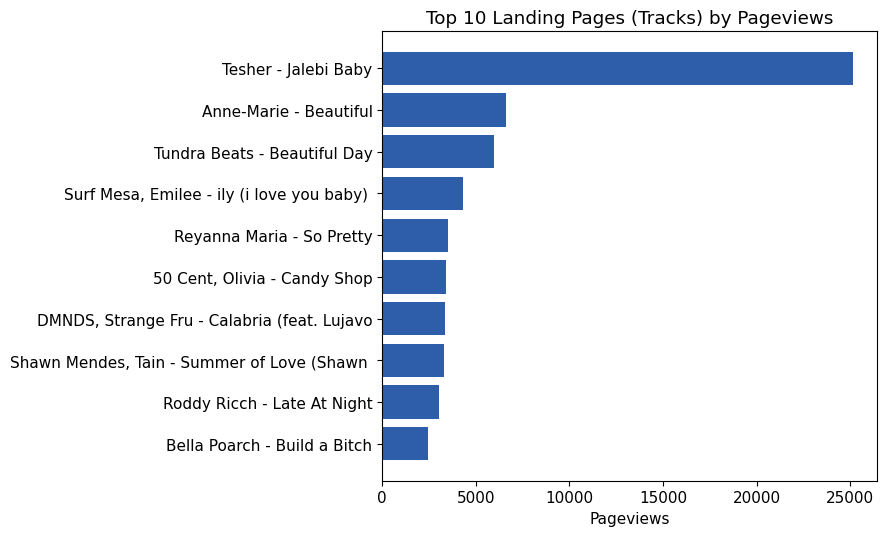

In [13]:
labels = [f"{a[:18]} - {t[:22]}" for a,t in zip(top_entry['artist'], top_entry['track'])]
fig, ax = plt.subplots(figsize=(9,5.5))
ax.barh(labels[::-1], top_entry['pageview'][::-1], color='#2E5EAA')
ax.set_xlabel('Pageviews')
ax.set_title('Top 10 Landing Pages (Tracks) by Pageviews')
plt.tight_layout()
plt.show()

## 7. Visualization 2 — Line Chart: Daily Event Trend

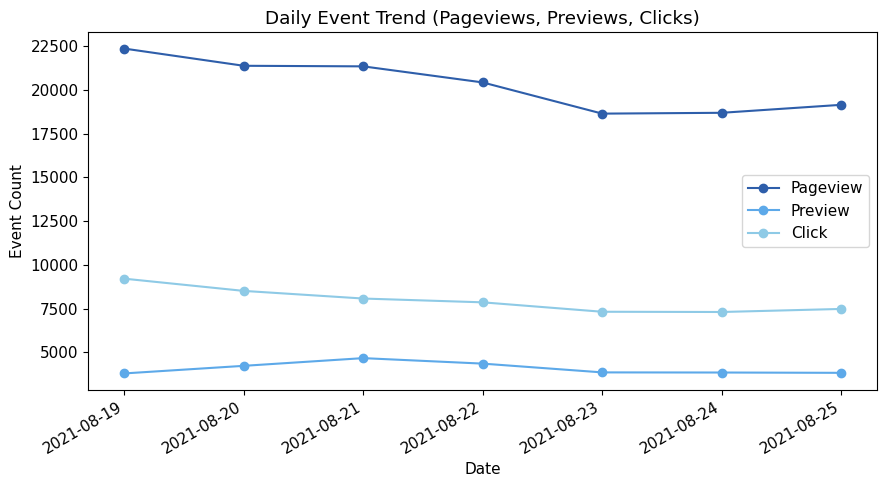

In [14]:
daily = df.groupby([df['date'].dt.date, 'event']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(9,5))
for col,color in zip(['pageview','preview','click'], COLORS):
    if col in daily.columns:
        ax.plot(daily.index, daily[col], marker='o', label=col.capitalize(), color=color)
ax.set_xlabel('Date'); ax.set_ylabel('Event Count')
ax.set_title('Daily Event Trend (Pageviews, Previews, Clicks)')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 8. Visualization 3 — Pie Chart: Event Type Distribution

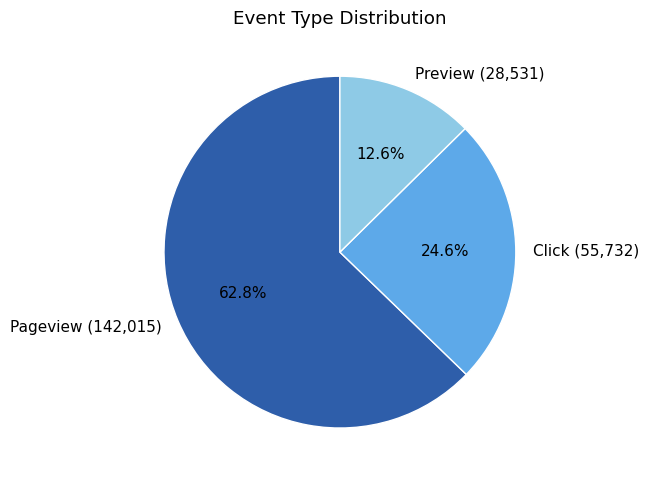

In [15]:
event_totals = df['event'].value_counts()
fig, ax = plt.subplots(figsize=(6.5,6.5))
ax.pie(event_totals, labels=[f"{i.capitalize()} ({v:,})" for i,v in event_totals.items()],
       autopct='%1.1f%%', colors=COLORS, startangle=90, wedgeprops={'edgecolor':'white'})
ax.set_title('Event Type Distribution')
plt.tight_layout()
plt.show()

## 9. Geography — Traffic by Country (proxy for referral source)

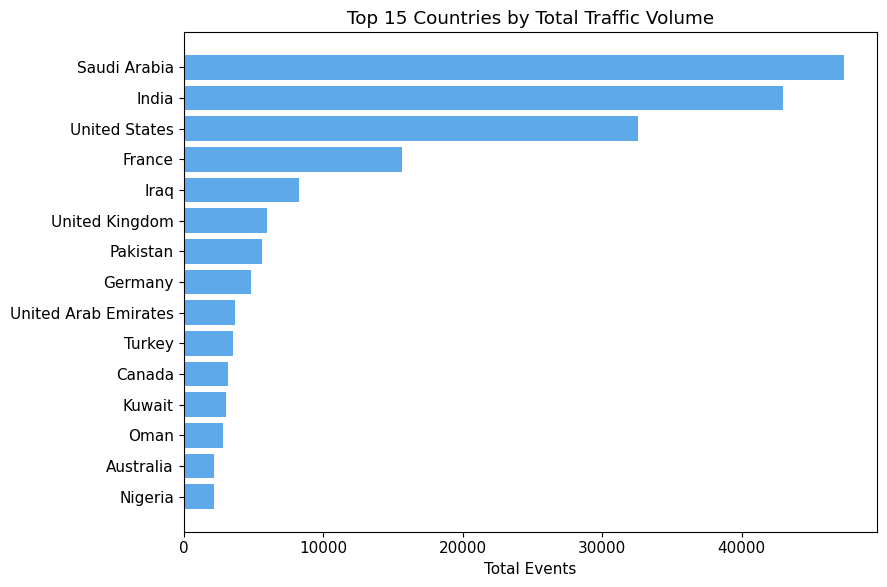

In [16]:
country_events = df.groupby('country').size().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(country_events.index[::-1], country_events.values[::-1], color='#5DA9E9')
ax.set_xlabel('Total Events')
ax.set_title('Top 15 Countries by Total Traffic Volume')
plt.tight_layout()
plt.show()

## 10. User Journey Funnel: Pageview → Preview → Click

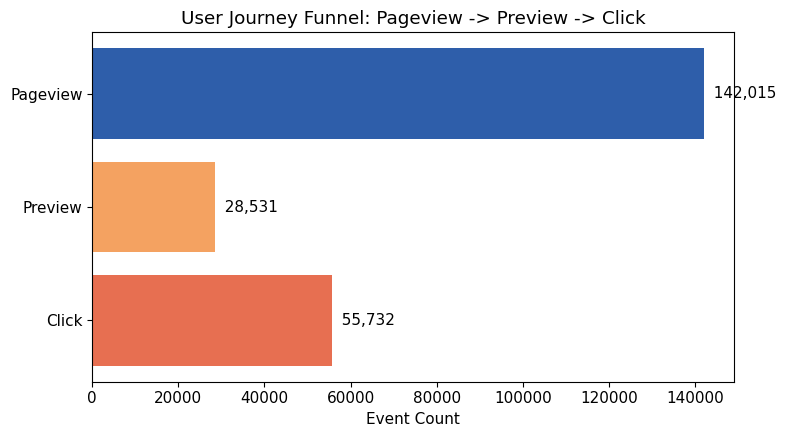

In [17]:
stages = ['Pageview','Preview','Click']
vals = [pageviews, previews, clicks]
fig, ax = plt.subplots(figsize=(8,4.5))
ax.barh(stages[::-1], vals[::-1], color=['#2E5EAA','#F4A261','#E76F51'][::-1])
for i,(s,v) in enumerate(zip(stages[::-1], vals[::-1])):
    ax.text(v, i, f'  {v:,}', va='center')
ax.set_xlabel('Event Count')
ax.set_title('User Journey Funnel: Pageview -> Preview -> Click')
plt.tight_layout()
plt.show()

**Reading this funnel:** because events aren't linked to individual users, this shows the *aggregate* volume drop-off across stages (not each visitor's individual path). It's the closest valid journey view the data supports.

## 11. Top Artists / Tracks by Engagement

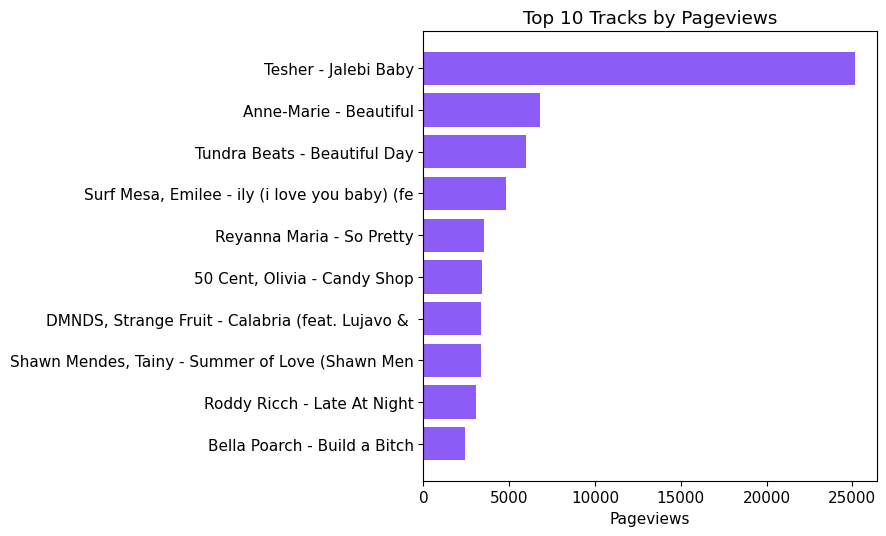

In [18]:
top_tracks = (df[df['event']=='pageview'].groupby(['artist','track']).size()
              .sort_values(ascending=False).head(10).reset_index(name='pageviews'))
top_tracks['label'] = top_tracks['artist'].str[:20] + ' - ' + top_tracks['track'].str[:25]
fig, ax = plt.subplots(figsize=(9,5.5))
ax.barh(top_tracks['label'][::-1], top_tracks['pageviews'][::-1], color='#8B5CF6')
ax.set_xlabel('Pageviews')
ax.set_title('Top 10 Tracks by Pageviews')
plt.tight_layout()
plt.show()

## 12. Key Insights Summary

1. **Traffic volume:** 226,278 total events over 7 days — 142,015 pageviews, 55,732 clicks, 28,531 previews.
2. **Overall click-through rate is ~39.2%**, and the preview rate is ~20.1% — meaning roughly 6 in 10 landing-page visits do not result in a click-through.
3. **Bounce-rate proxy is ~40%** — 4 in 10 landing pages receive pageviews with zero downstream engagement (no click, no preview) for the whole week.
4. **Traffic is heavily concentrated**: one track ("Jalebi Baby" by Tesher) drives ~18% of all pageviews — a single-point-of-failure risk if that campaign fades.
5. **Geographic concentration:** Saudi Arabia, India and the United States together account for the largest share of traffic, with several fast-growing secondary markets (Iraq, UK, Pakistan).
6. Long-tail landing pages with ≥50 pageviews but <25% CTR represent clear conversion drop-off — mostly niche or non-English tracks and instrumentals, or tracks where the artwork/preview may be misleading users' expectations.

## 13. Recommended Optimizations for Alfido Tech

1. **Fix high-traffic, low-conversion landing pages first.** Focus on tracks with ≥50 pageviews and <25% CTR (see Section 5) — audit thumbnail art, preview audio, and CTA button placement/copy on those specific pages before broader changes.
2. **Reduce reliance on a single hit track.** "Jalebi Baby" alone drives ~18% of pageviews; diversify promotion across the next 10-15 tracks so a decline in one campaign doesn't sink total traffic.
3. **Convert "preview" behavior into clicks.** ~20% of visitors preview but a portion never click through — test moving the primary streaming CTA above/beside the preview player, or auto-suggesting the CTA immediately after preview playback ends.
4. **Double down on top-performing geographies while testing localization in growth markets.** Saudi Arabia, India, and the US lead volume — ensure store links, language, and currency are geo-optimized there, and A/B test localized landing copy in the next tier of countries (Iraq, UK, Pakistan, UAE, Turkey).
5. **Instrument the funnel properly going forward.** Add session IDs, event timestamps, and a referrer/UTM field to the tracking pipeline — this unlocks true session counts, session duration, real bounce rate, and actual traffic-source attribution (organic, paid, social, direct) for far more precise future optimization.